In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import block_diag

import ex_duffing
import util_data

In [2]:
# --! define a reward function --!

class quadratic_fun:
    def __init__(self, matrix):
        self.matrix = np.atleast_2d(matrix)

    def __call__(self, x):
        return np.dot(x, np.dot(self.matrix, x.T))

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 1.0 * np.eye(action_ndim)

reward = quadratic_fun(block_diag(-state_cost, -action_cost))

In [3]:

duffing_ood = ex_duffing.make_duffing('ood', reward)
policy = ex_duffing.make_policy(duffing_ood, q=state_cost, r=action_cost, noise=0)
duffing_ood.policy = policy

duffing_id = ex_duffing.make_duffing('id', reward)
policy = ex_duffing.make_policy(duffing_id, q=state_cost, r=action_cost, noise=0)
duffing_id.policy = policy

data_exc = duffing_ood.simulate(skip_nsample=2_000)
data_nom = duffing_id.simulate(skip_nsample=2_000)


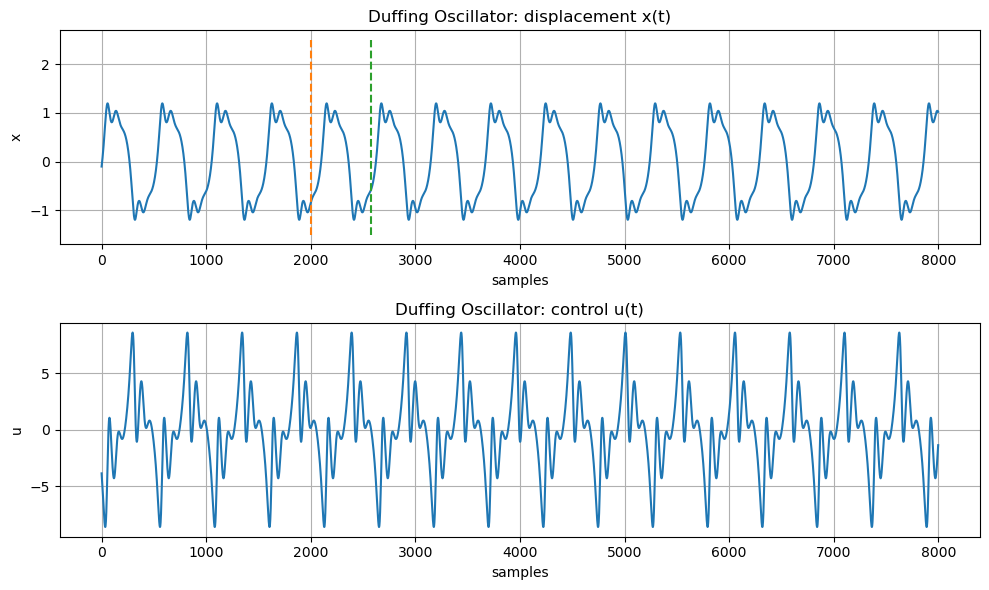

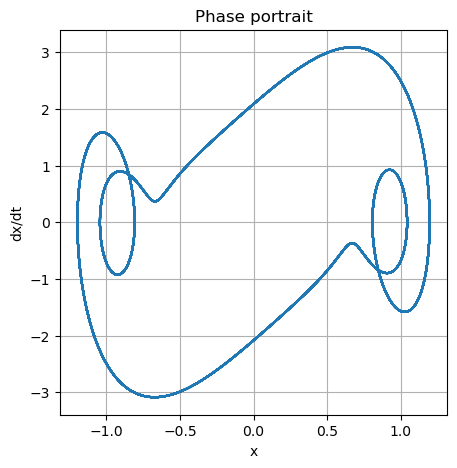

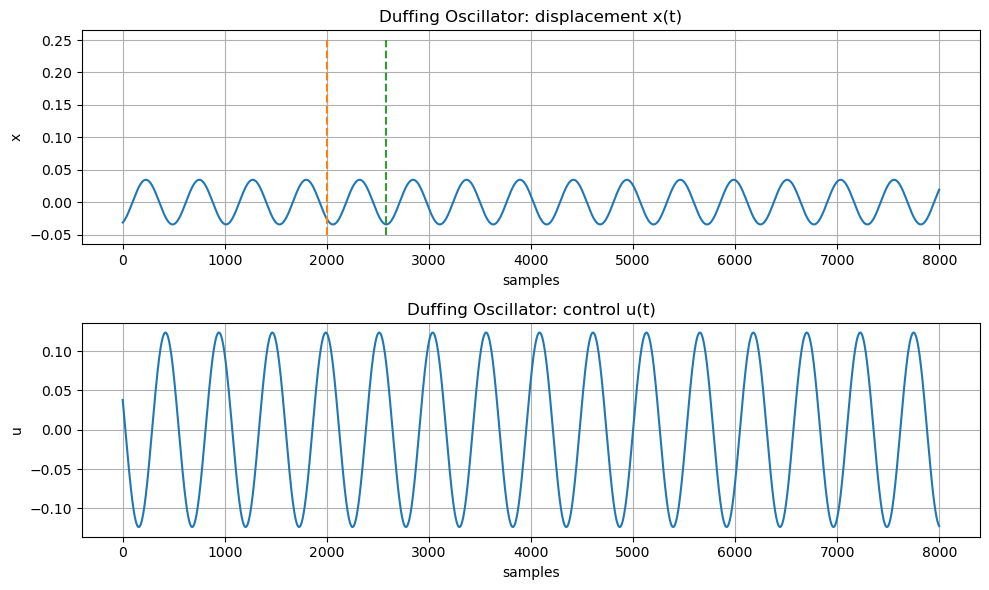

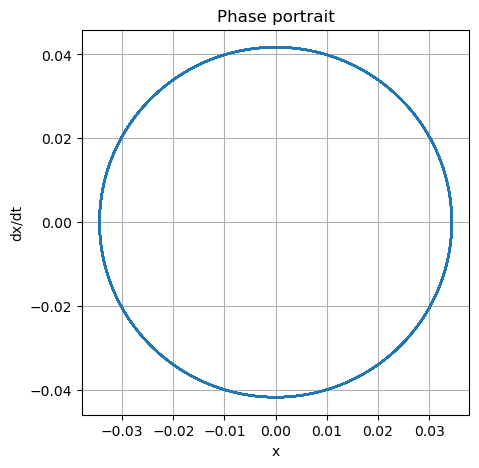

In [4]:
# --! plot results --!

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(data_exc[0, :, 0])
plt.plot([2000, 2000], [-1.5, 2.5], linestyle='dashed')
plt.plot([2576, 2576], [-1.5, 2.5], linestyle='dashed')
plt.title("Duffing Oscillator: displacement x(t)")
plt.xlabel("samples")
plt.ylabel("x")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(data_exc[0, :, 2])
plt.title("Duffing Oscillator: control u(t)")
plt.xlabel("samples")
plt.ylabel("u")
plt.grid(True)

plt.tight_layout()
plt.show()

# --! phase portrait
plt.figure(figsize=(5,5))
plt.plot(data_exc[0, :, 0], data_exc[0, :, 1])
plt.title("Phase portrait")
plt.xlabel("x")
plt.ylabel("dx/dt")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(data_nom[0, :, 0])
plt.plot([2000, 2000], [-0.05, 0.25], linestyle='dashed')
plt.plot([2576, 2576], [-0.05, 0.25], linestyle='dashed')
plt.title("Duffing Oscillator: displacement x(t)")
plt.xlabel("samples")
plt.ylabel("x")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(data_nom[0, :, 2])
plt.title("Duffing Oscillator: control u(t)")
plt.xlabel("samples")
plt.ylabel("u")
plt.grid(True)

plt.tight_layout()
plt.show()

# --! phase portrait
plt.figure(figsize=(5,5))
plt.plot(data_nom[0, :, 0], data_nom[0, :, 1])
plt.title("Phase portrait")
plt.xlabel("x")
plt.ylabel("dx/dt")
plt.grid(True)
plt.show()

In [5]:
# --! save simulated data --!

def cat_mask(data):
    """ Concatenates mask dimension to main simulated data dimensions. """
    mask = np.ones((data.shape[0], data.shape[1], 1))
    return np.concatenate([data, mask], axis=-1)

datasaved = True

if datasaved:
    savedata = np.concatenate([cat_mask(data) for data in [data_nom]], axis=0)
    print(f'nominal data saved with a shape {savedata.shape}')
    savedir = '../../data/dreamer'
    util_data.write_datafile(f'{savedir}/duffing_nom', savedata)

    savedata = np.concatenate([cat_mask(data) for data in [data_exc]], axis=0)
    print(f'excursion data saved with a shape {savedata.shape}')
    savedir = '../../data/dreamer'
    util_data.write_datafile(f'{savedir}/duffing_exc', savedata)

nominal data saved with a shape (1, 8000, 4)
excursion data saved with a shape (1, 8000, 4)
